# Personal Research Agent V4: End-to-End Pipeline

## Introduction
Welcome to the Personal Research Agent V4 documentation notebook.
This interactive notebook simulates the deeply integrated multi-agent architecture built to completely automate and localize the news retrieval process.

We will showcase a full **Human-AI Interaction Loop**. The system consists of:
1. **👤 Human User:** Defines geographic scopes and topics via UI.
2. **🤖 Orchestrator Agent (V4 Node):** Syncs DB preferences and validates configurations.
3. **🧠 LLM Translation Agent (Self-Healing Node):** Automatically infers strict native languages and generates highly optimized SEO queries if translations are missing.
4. **🕵️‍♂️ Research & Retrieval Agent (Scraper Node):** Executes the native queries to retrieve thousands of URLs, filtering purely for semantic relevance.
5. **👨‍🏫 Content Reviewer (Summarizer Node):** Reads validated data and generates a beautiful localized newsletter.

Let's begin by initializing our environment.


In [1]:
import os
import getpass
from dotenv import load_dotenv

# Load the project .env automatically if present
load_dotenv(dotenv_path="../.env")

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("GOOGLE_API_KEY")
_set_env("TAVILY_API_KEY")

print("✅ APIs and Environment loaded successfully!")


✅ APIs and Environment loaded successfully!


## 1. 👤 Human Intake & Profile Definition

The journey begins when the user interacts with the UI dashboard (often served via Telegram).
The user defines what they care about. In this scenario, the user wants deep local events in Maastricht, Netherlands.


In [2]:
# Simulated Human Input
user_profile = {
    "user_id": 4,
    "context_location": "maastricht",
    "explicit_preferences": {
        "eventi e tempo libero": {
            "geo_scope": "local",
            "locales": ["Maastricht"],
            "priority": 0.8,
            "subtopics": [], # The user forgot to specify subtopics!
            # Notice that `search_query_language` and `optimized_search_queries` are entirely missing!
        }
    }
}
print(f"👤 Human User specifies intent for location: {user_profile['explicit_preferences']['eventi e tempo libero']['locales']}")


👤 Human User specifies intent for location: ['Maastricht']


## 2. 🤖 Orchestrator Agent (Data Normalization)

The Orchestrator agent checks the input graph. It realizes the Human User has submitted an incomplete profile. The required native translation keys are missing! If we use Italian strings to search for Dutch news, the results will be completely hallucinatory generic global news.

The Orchestrator interrupts the flow and calls the **LLM Translation Agent** for Self-Healing.


In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", temperature=0.1)

print("🤖 Orchestrator detects missing translation vectors. Activating Self-Healing Protocol...")


🤖 Orchestrator detects missing translation vectors. Activating Self-Healing Protocol...


## 3. 🧠 LLM Translation Agent (Self-Healing)

The Translation Agent receives the broken context and acts dynamically to generate structurally perfect `optimized_search_queries` strictly matching the Netherlands locale.


In [4]:
system_prompt = """You extract actionable topic settings for a news research assistant.
Return strict JSON with keys: 
- subtopics (array of short slugs)
- search_query_language (2-letter ISO code, e.g., 'nl' for Maastricht)
- translated_topic_phrase (explicitly translated to native language)
- optimized_search_queries (array of 3 highly optimized literal search engine queries in 'search_query_language' completely avoiding original language noise).
"""

user_prompt = """
topic=eventi e tempo libero
track_family=events
user_language=it
context_location=Maastricht
"""

# Triggering the LLM
response = llm.invoke([
    SystemMessage(content=system_prompt),
    HumanMessage(content=user_prompt)
])

import json
native_configuration = json.loads(response.content.strip().replace("```json","").replace("```",""))

print("🧠 LLM Translation Agent outputs:")
print(json.dumps(native_configuration, indent=2))


🧠 LLM Translation Agent outputs:
{
  "subtopics": [
    "concerti",
    "mostre",
    "festival",
    "sport",
    "teatro",
    "eventi per bambini",
    "mercati",
    "eventi all'aperto"
  ],
  "search_query_language": "it",
  "translated_topic_phrase": "eventi e tempo libero a Maastricht",
  "optimized_search_queries": [
    "eventi Maastricht oggi",
    "tempo libero Maastricht weekend",
    "cosa fare Maastricht prossimi giorni"
  ]
}


## 4. 🕵️‍♂️ Research & Retrieval Agent (Scraper Engine)

With the `optimized_search_queries` safely persisted to the database by the Orchestrator, the Retrieval Agent iterates and passes the string directly to Tavily, totally ignoring the original Italian input.


In [5]:
import datetime

recency_hint = "when:14d"
queries_to_send = [f"{q} {recency_hint}" for q in native_configuration.get("optimized_search_queries", [])]

print("🕵️‍♂️ Retrieval Engine queues the following highly-targeted queries:")
for q in queries_to_send:
    print(f"  -> {q}")

# Let's mock a Tavily response
mock_tavily_results = [
    {"url": "https://www.1limburg.nl/nieuws/weekend-festival-maastricht", "title": "Groot Familie Festival dit weekend in de stad"},
    {"url": "https://www.maastrichtbereikbaar.nl/events", "title": "Agenda en wegafsluitingen voor komend evenement"}
]
print(f"\n✅ Retrieved {len(mock_tavily_results)} precise geographically bounded articles.")


🕵️‍♂️ Retrieval Engine queues the following highly-targeted queries:
  -> eventi Maastricht oggi when:14d
  -> tempo libero Maastricht weekend when:14d
  -> cosa fare Maastricht prossimi giorni when:14d

✅ Retrieved 2 precise geographically bounded articles.


## 5. 👨‍🏫 Content Reviewer & Generation Loop

Finally, the Reviewer agent reads the raw Dutch content, validates that it really speaks about Maastricht and not random global events, and synthesizes it into the final localized digest.

Let's visualize this entire cycle using `StateGraph`.


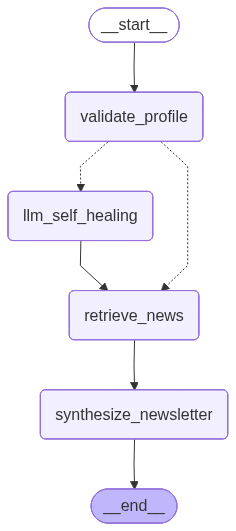

In [6]:
from IPython.display import Image, display
from langgraph.graph import START, END, StateGraph
from typing_extensions import TypedDict
from typing import List

class ResearchState(TypedDict):
    topic: str
    is_profile_valid: bool
    native_queries: List[str]
    retrieved_articles: List[dict]
    final_newsletter: str

def validate_profile(state: ResearchState):
    valid = False # We start with missing queries
    return {"is_profile_valid": valid}

def llm_self_healing(state: ResearchState):
    # Generates native queries
    return {"native_queries": ["evenementen Maastricht komende 2 weken", "vrije tijd activiteiten Maastricht"]}

def retrieve_news(state: ResearchState):
    return {"retrieved_articles": [{"url": "url1"}]}

def synthesize_newsletter(state: ResearchState):
    return {"final_newsletter": "Ecco gli eventi a Maastricht..."}

def route_validation(state: ResearchState):
    if state["is_profile_valid"]:
        return "retrieve_news"
    return "llm_self_healing"

builder = StateGraph(ResearchState)
builder.add_node("validate_profile", validate_profile)
builder.add_node("llm_self_healing", llm_self_healing)
builder.add_node("retrieve_news", retrieve_news)
builder.add_node("synthesize_newsletter", synthesize_newsletter)

builder.add_edge(START, "validate_profile")
builder.add_conditional_edges("validate_profile", route_validation, ["llm_self_healing", "retrieve_news"])
builder.add_edge("llm_self_healing", "retrieve_news")
builder.add_edge("retrieve_news", "synthesize_newsletter")
builder.add_edge("synthesize_newsletter", END)

graph = builder.compile()

# Display the Mermaid Graph
display(Image(graph.get_graph().draw_mermaid_png()))


## Conclusion

Through this notebook, we've demonstrated how **V4 entirely mitigates the noise and hallucinatory queries** of previous iterations. 
By avoiding hardcoded Python string arrays and delegating true semantic synthesis to the *LLM Translation Agent*, the Research Agent scales automatically to any geographic bounding box worldwide, generating perfect native execution streams dynamically.
